In [1]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import contextily as ctx
import numpy as np
import matplotlib.pyplot as plt

cows = pd.read_csv("../Data/dades_clusters.csv")
cols = ["id", "night_date", "lat", "lng", "elevation", "cluster_norm1"]
cows_cluster = cows[cols].copy()
cows_cluster

,id,night_date,lat,lng,elevation,cluster_norm1
0,AJ701_2022,2022-07-04,42.368795,2.255116,1874.0,-1
1,AJ701_2022,2022-07-05,42.371786,2.248280,2095.0,8
2,AJ701_2022,2022-07-06,42.377401,2.248096,2091.0,32
3,AJ701_2022,2022-07-07,42.379431,2.245106,2261.0,31
4,AJ701_2022,2022-07-08,42.371725,2.243290,2247.0,23
...,...,...,...,...,...,...
15230,CJ375_2023,2023-10-22,42.379110,2.262638,1924.0,16
15231,CJ375_2023,2023-10-23,42.379736,2.263325,1969.0,16
15232,CJ375_2023,2023-10-24,42.377859,2.269841,1950.0,7
15233,CJ375_2023,2023-10-25,42.377890,2.264744,1929.0,15


In [2]:
from utilities import set_article_style

gdf = gpd.GeoDataFrame(
    cows,
    geometry=gpd.points_from_xy(cows["lng"], cows["lat"]),
    crs="EPSG:4326"
)


# Filter out outliers (cluster_id == -1)
clustered_gdf = gdf[gdf["cluster_norm1"] != -1].copy()

# Make sure it's in Web Mercator (EPSG:3857) for contextily basemap
if clustered_gdf.crs.to_epsg() != 3857:
    clustered_gdf = clustered_gdf.to_crs(epsg=3857)

# --- 2. Shuffle the Labels for Visual Contrast ---
# Extract unique cluster IDs
unique_clusters = clustered_gdf["cluster_norm1"].unique()

# Seed the generator so your plot colors stay consistent every time you run it
#id_num = np.random.randint(1000)
#print(id_num)

rng = np.random.default_rng(seed=231) 
shuffled_clusters = unique_clusters.copy()
rng.shuffle(shuffled_clusters)

# Create a mapping dictionary {original_label: shuffled_visual_index}
cluster_color_map = {orig: i for i, orig in enumerate(shuffled_clusters)}

# Map to a temporary column used solely for the color gradient
clustered_gdf["visual_color_id"] = clustered_gdf["cluster_norm1"].map(cluster_color_map)
    

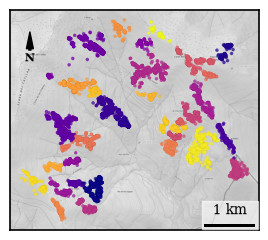

In [7]:
#Plots the clustered points with a map and scalebar.

from matplotlib_scalebar.scalebar import ScaleBar 

set_article_style()
fig, ax = plt.subplots(figsize=(3.375, 2.5))

# Plot GeoDataFrame
clustered_gdf.plot(
    column="visual_color_id",
    categorical=True,
    cmap="plasma_r",
    legend=False, 
    ax=ax, 
    markersize=6,
    alpha=0.75,
    edgecolor="black",
    linewidth=0.01
)

# Add ICGC basemap
icgc_gris_url = "https://geoserveis.icgc.cat/servei/catalunya/mapa-base/wmts/topografic-gris/MON3857NW/{z}/{x}/{y}.png"
ctx.add_basemap(ax, source=icgc_gris_url)

ax.set_xticks([])
ax.set_yticks([])

scalebar = ScaleBar(
    dx=1,                 
    units="m",
    dimension="si-length",
    location="lower right",
    fixed_value=1,         
    fixed_units="km",
    scale_loc="top",
    box_alpha=0.6,
    color="black"
)
ax.add_artist(scalebar)

ax.annotate(
    'N', 
    xy=(0.08, 0.90),        # Arrow point position
    xytext=(0.08, 0.78),    # Arrow tail position
    arrowprops=dict(facecolor='black', width=1.5, headwidth=5),
    ha='center', va='center', 
    xycoords='axes fraction',
    fontsize=8,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig("../Plots/Article/cluster_norm1.png", dpi=300)
plt.show()